# 💻 Laptop Price Prediction — Linear Regression with Gradient Descent
> **Pipeline:** Data Loading → EDA → Preprocessing → Feature Engineering → Gradient Descent (from scratch) → Evaluation


## 1️⃣ Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

print("✅ Libraries loaded successfully")


✅ Libraries loaded successfully


## 2️⃣ Load Dataset

In [2]:
df = pd.read_csv("laptop_data.csv")
print(f"Shape: {df.shape}")
df.head()


Shape: (1303, 12)


,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 122.3+ KB


In [4]:
df.describe()


,Unnamed: 0,Inches,Price
count,1303.00000,1303.000000,1303.000000
mean,651.00000,15.017191,59870.042910
std,376.28801,1.426304,37243.201786
min,0.00000,10.100000,9270.720000
25%,325.50000,14.000000,31914.720000
50%,651.00000,15.600000,52054.560000
75%,976.50000,15.600000,79274.246400
max,1302.00000,18.400000,324954.720000


## 3️⃣ Exploratory Data Analysis (EDA)
> Quick visual overview of how each feature relates to **Price**


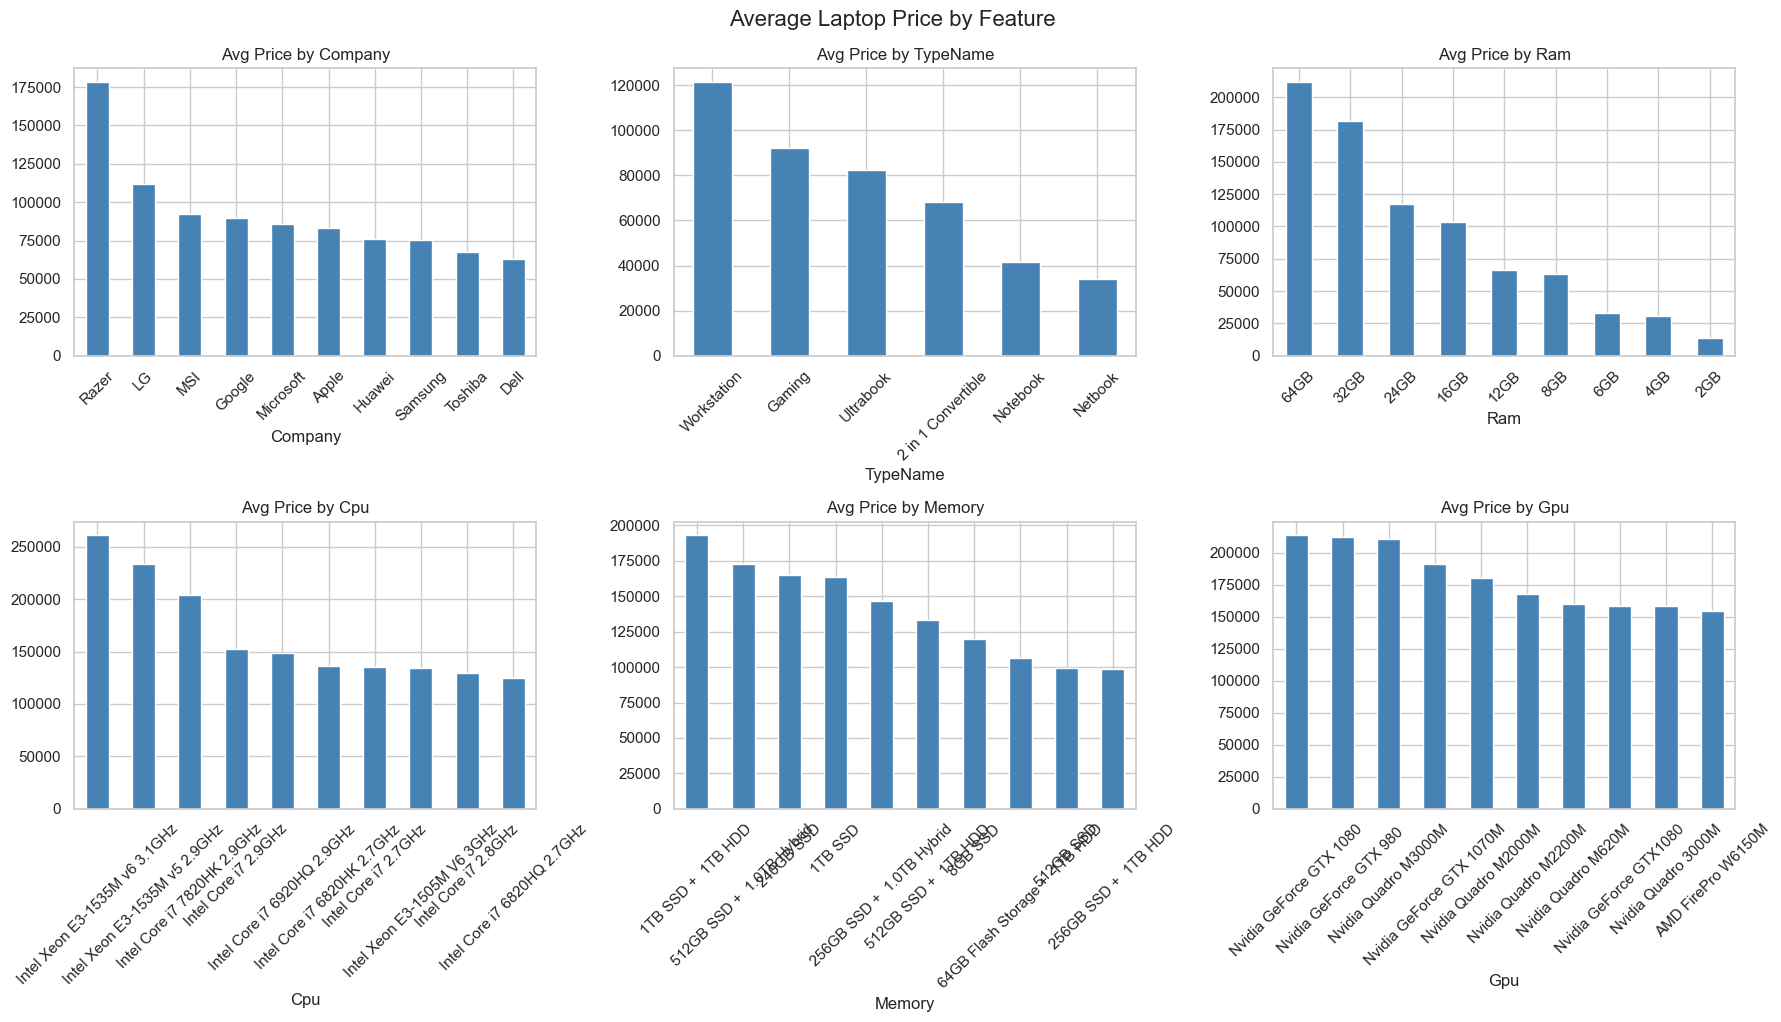

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

group_cols = ["Company", "TypeName", "Ram", "Cpu", "Memory", "Gpu"]
for i, col in enumerate(group_cols):
    top = df.groupby(col)["Price"].mean().sort_values(ascending=False).head(10)
    top.plot(kind="bar", ax=axes[i], title=f"Avg Price by {col}", color="steelblue")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.suptitle("Average Laptop Price by Feature", fontsize=16, y=1.02)
plt.show()


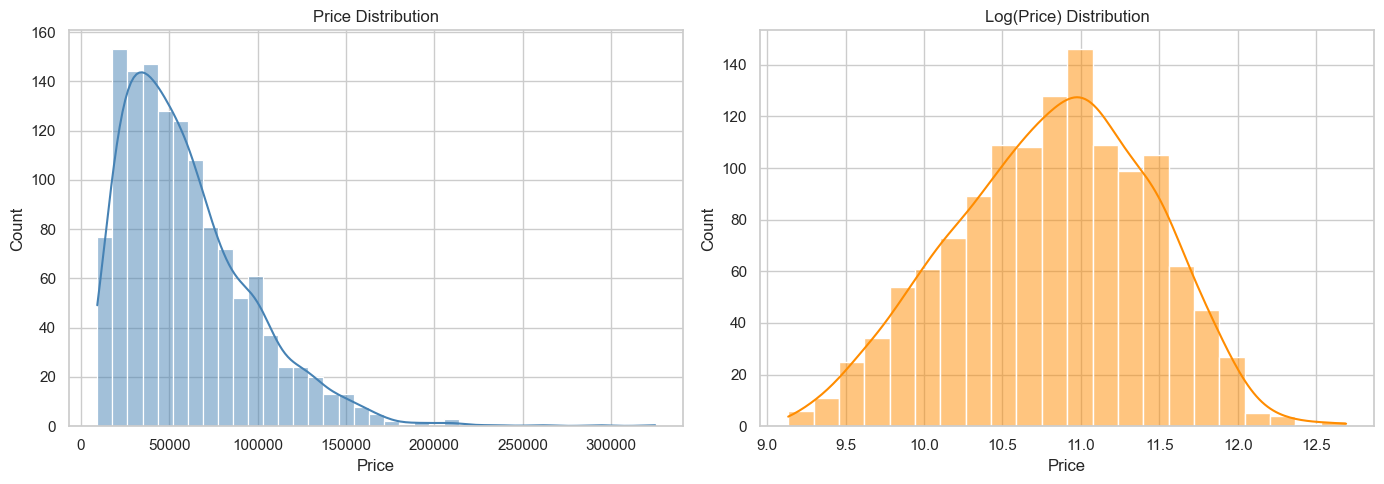

In [6]:
# Price distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["Price"], kde=True, ax=ax1, color="steelblue")
ax1.set_title("Price Distribution")

sns.histplot(np.log1p(df["Price"]), kde=True, ax=ax2, color="darkorange")
ax2.set_title("Log(Price) Distribution")

plt.tight_layout()
plt.show()


## 4️⃣ Data Cleaning

In [7]:
# Drop index column if present
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)

# Check nulls
print("Missing values:\n", df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

# Convert Ram: '8GB' → 8.0
df["Ram"] = df["Ram"].str.replace("GB", "", regex=False).astype(float)

# Convert Weight: '1.37kg' → 1.37
df["Weight"] = df["Weight"].str.replace("kg", "", regex=False).astype(float)

print("\n✅ Cleaning done. New shape:", df.shape)


Missing values:
 Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

Duplicate rows: 29

✅ Cleaning done. New shape: (1274, 11)


## 5️⃣ Feature Engineering
### 🔧 CPU, Screen Resolution, Memory, GPU


In [8]:
# ── CPU ──
df["Cpu_Brand"] = df["Cpu"].apply(lambda x: x.split()[0])
df["Cpu_Type"]  = df["Cpu"].apply(lambda x: x.split()[1] if len(x.split()) > 1 else "Unknown")
df["Cpu_Speed"] = df["Cpu"].apply(lambda x: x.split()[-1].replace("GHz", "")).astype(float)

# ── Screen Resolution ──
df["resolution_width"]  = df["ScreenResolution"].apply(lambda x: int(re.search(r'(\d+)x(\d+)', x).group(1)))
df["resolution_height"] = df["ScreenResolution"].apply(lambda x: int(re.search(r'(\d+)x(\d+)', x).group(2)))
df["is_touchscreen"]    = df["ScreenResolution"].apply(lambda x: 1 if "Touchscreen" in x else 0)
df["is_ips"]            = df["ScreenResolution"].apply(lambda x: 1 if "IPS" in x else 0)
df["ppi"]               = (df["resolution_width"]**2 + df["resolution_height"]**2)**0.5 / df["Inches"]

# ── Memory ──
def convert_memory(value):
    value = value.strip()
    if "TB" in value:
        return int(float(value.replace("TB", "")) * 1000)
    return int(value.replace("GB", ""))

for col in ["SSD", "HDD", "Flash", "Hybrid"]:
    df[col] = 0

for i in df.index:
    for part in df.loc[i, "Memory"].split("+"):
        part = part.strip()
        try:
            size = convert_memory(part.split()[0])
        except:
            size = 0
        if "SSD"    in part: df.loc[i, "SSD"]    += size
        elif "HDD"  in part: df.loc[i, "HDD"]    += size
        elif "Flash"in part: df.loc[i, "Flash"]  += size
        elif "Hybrid"in part:df.loc[i, "Hybrid"] += size

# ── GPU Brand ──
df["Gpu_Brand"] = df["Gpu"].apply(lambda x: x.split()[0])

# Drop raw text columns
df.drop(columns=["Cpu", "ScreenResolution", "Gpu", "Memory", "Cpu_Type"], inplace=True)

print("✅ Feature engineering done. Shape:", df.shape)
df.head(3)


✅ Feature engineering done. Shape: (1274, 19)


,Company,TypeName,Inches,Ram,OpSys,Weight,Price,Cpu_Brand,Cpu_Speed,resolution_width,resolution_height,is_touchscreen,is_ips,ppi,SSD,HDD,Flash,Hybrid,Gpu_Brand
0,Apple,Ultrabook,13.3,8.0,macOS,1.37,71378.6832,Intel,2.3,2560,1600,0,1,226.983005,128,0,0,0,Intel
1,Apple,Ultrabook,13.3,8.0,macOS,1.34,47895.5232,Intel,1.8,1440,900,0,0,127.677940,0,0,128,0,Intel
2,HP,Notebook,15.6,8.0,No OS,1.86,30636.0000,Intel,2.5,1920,1080,0,0,141.211998,256,0,0,0,Intel


## 6️⃣ Encoding & Feature Scaling

In [9]:
# One-Hot Encoding
cat_cols = ["Company", "TypeName", "Cpu_Brand", "Gpu_Brand", "OpSys"]
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Separate features and target
X = df.drop("Price", axis=1).copy()
y = df["Price"].values.reshape(-1, 1)

print("Features shape:", X.shape)
print("Target shape:  ", y.shape)


Features shape: (1274, 49)
Target shape:   (1274, 1)


In [10]:
# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale numerical features only
num_cols = [
    "Inches", "Ram", "Weight", "Cpu_Speed",
    "resolution_width", "resolution_height", "ppi",
    "SSD", "HDD", "Flash", "Hybrid"
]

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

X_train_np = X_train.values
X_test_np  = X_test.values
y_train_np = y_train.flatten()
y_test_np  = y_test.flatten()

print(f"Train: {X_train_np.shape}  |  Test: {X_test_np.shape}")


Train: (1019, 49)  |  Test: (255, 49)


## 7️⃣ Linear Regression — Gradient Descent from Scratch

$$\hat{y} = X \cdot w + b$$

$$\text{MSE} = \frac{1}{n} \sum (\hat{y}_i - y_i)^2$$

$$w := w - \alpha \cdot \frac{\partial \text{MSE}}{\partial w} \qquad b := b - \alpha \cdot \frac{\partial \text{MSE}}{\partial b}$$


In [13]:
class LinearRegressionGD:
    """Linear Regression trained via Batch Gradient Descent."""

    def __init__(self, learning_rate=0.01, n_iterations=1000, verbose=True, log_every=100):
        self.lr           = learning_rate
        self.n_iterations = n_iterations
        self.verbose      = verbose
        self.log_every    = log_every

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias    = 0.0
        self.loss_history = []

        for i in range(1, self.n_iterations + 1):
            y_pred = X @ self.weights + self.bias
            error  = y_pred - y

            # Gradients
            dw = (2 / n_samples) * (X.T @ error)
            db = (2 / n_samples) * error.sum()

            # Update
            self.weights -= self.lr * dw
            self.bias    -= self.lr * db

            # Record loss
            mse = np.mean(error ** 2)
            self.loss_history.append(mse)

            if self.verbose and i % self.log_every == 0:
                print(f"Iter {i:5d} | MSE: {mse:,.2f}")

        return self

    def predict(self, X):
        return X @ self.weights + self.bias


In [14]:
model_gd = LinearRegressionGD(
    learning_rate=0.01,
    n_iterations=1000,
    verbose=True,
    log_every=100
)
X_train_np = X_train_np.astype(float)
X_test_np = X_test_np.astype(float)
model_gd.fit(X_train_np, y_train_np)


Iter   100 | MSE: 395,672,993.79
Iter   200 | MSE: 365,116,983.99
Iter   300 | MSE: 349,697,208.97
Iter   400 | MSE: 339,620,916.00
Iter   500 | MSE: 332,396,221.55
Iter   600 | MSE: 326,873,579.77
Iter   700 | MSE: 322,445,678.33
Iter   800 | MSE: 318,770,247.71
Iter   900 | MSE: 315,643,325.76
Iter  1000 | MSE: 312,936,277.57


## 8️⃣ Training Loss Curve

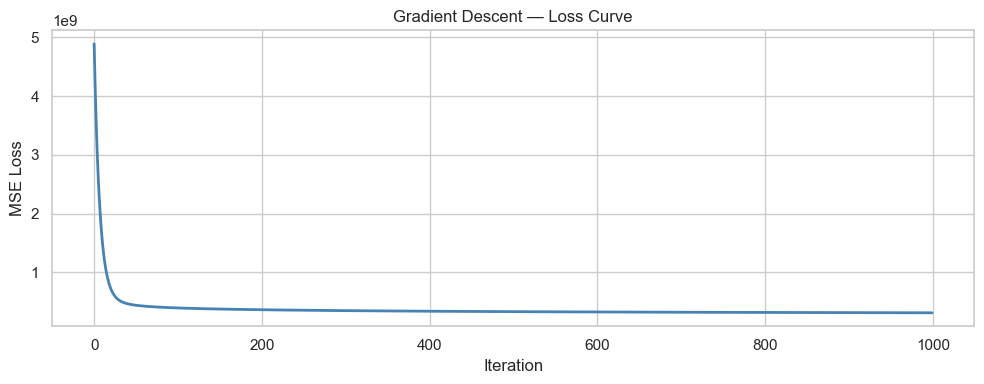

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(model_gd.loss_history, color="steelblue", linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Gradient Descent — Loss Curve")
plt.tight_layout()
plt.show()


## 9️⃣ Evaluation

In [16]:
y_pred_train = model_gd.predict(X_train_np)
y_pred_test  = model_gd.predict(X_test_np)

train_r2   = r2_score(y_train_np, y_pred_train)
test_r2    = r2_score(y_test_np,  y_pred_test)
train_rmse = np.sqrt(mean_squared_error(y_train_np, y_pred_train))
test_rmse  = np.sqrt(mean_squared_error(y_test_np,  y_pred_test))

print("=" * 40)
print(f"  Train R²  : {train_r2:.4f}")
print(f"  Test  R²  : {test_r2:.4f}")
print(f"  Train RMSE: {train_rmse:,.2f}")
print(f"  Test  RMSE: {test_rmse:,.2f}")
print("=" * 40)


  Train R²  : 0.7612
  Test  R²  : 0.7575
  Train RMSE: 17,689.29
  Test  RMSE: 20,384.16


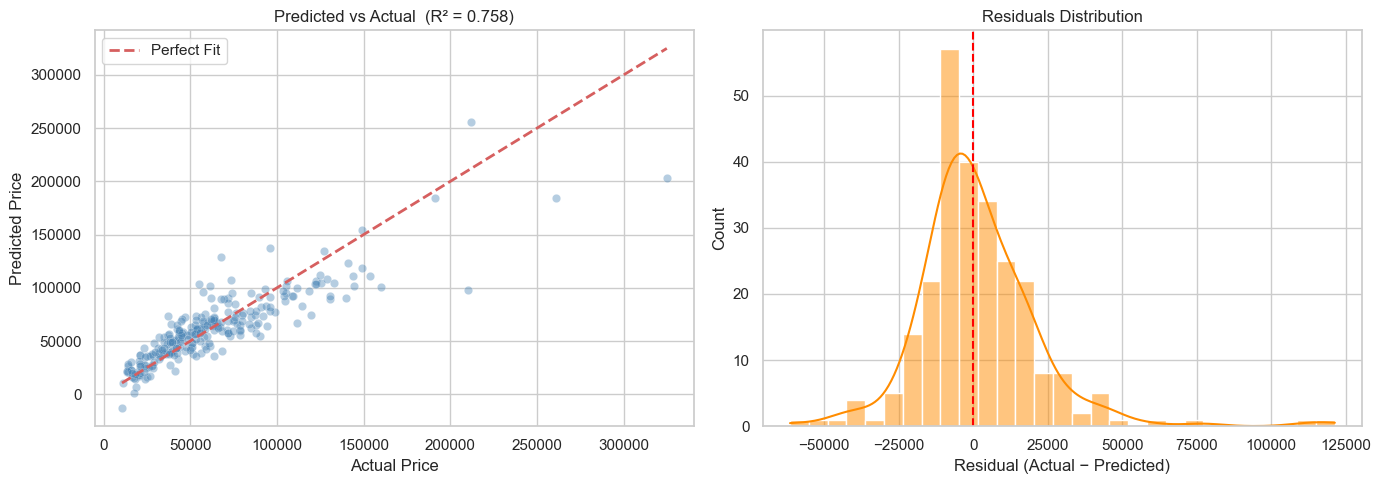

In [17]:
# Predicted vs Actual scatter plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(y_test_np, y_pred_test, alpha=0.4, color="steelblue", edgecolors="white", linewidth=0.3)
ax1.plot([y_test_np.min(), y_test_np.max()], [y_test_np.min(), y_test_np.max()],
         "r--", linewidth=2, label="Perfect Fit")
ax1.set_xlabel("Actual Price")
ax1.set_ylabel("Predicted Price")
ax1.set_title(f"Predicted vs Actual  (R² = {test_r2:.3f})")
ax1.legend()

# Residuals distribution
residuals = y_test_np - y_pred_test
sns.histplot(residuals, kde=True, ax=ax2, color="darkorange")
ax2.axvline(0, color="red", linestyle="--")
ax2.set_title("Residuals Distribution")
ax2.set_xlabel("Residual (Actual − Predicted)")

plt.tight_layout()
plt.show()


## 🔟 Top Feature Importances (by |weight|)

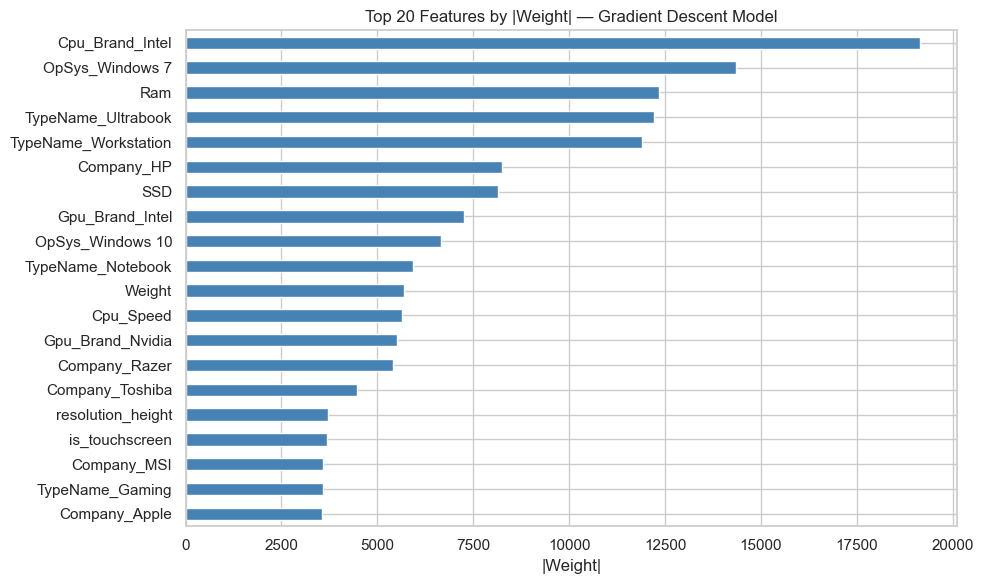

In [18]:
importance = pd.Series(np.abs(model_gd.weights), index=X_train.columns)
top20 = importance.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top20.sort_values().plot(kind="barh", color="steelblue")
plt.title("Top 20 Features by |Weight| — Gradient Descent Model")
plt.xlabel("|Weight|")
plt.tight_layout()
plt.show()


## 1️⃣1️⃣ Hyperparameter Tuning — Learning Rate Comparison

lr=0.001  →  Test R²: 0.7031
lr=0.005  →  Test R²: 0.7409
lr=0.010  →  Test R²: 0.7575
lr=0.050  →  Test R²: 0.7839


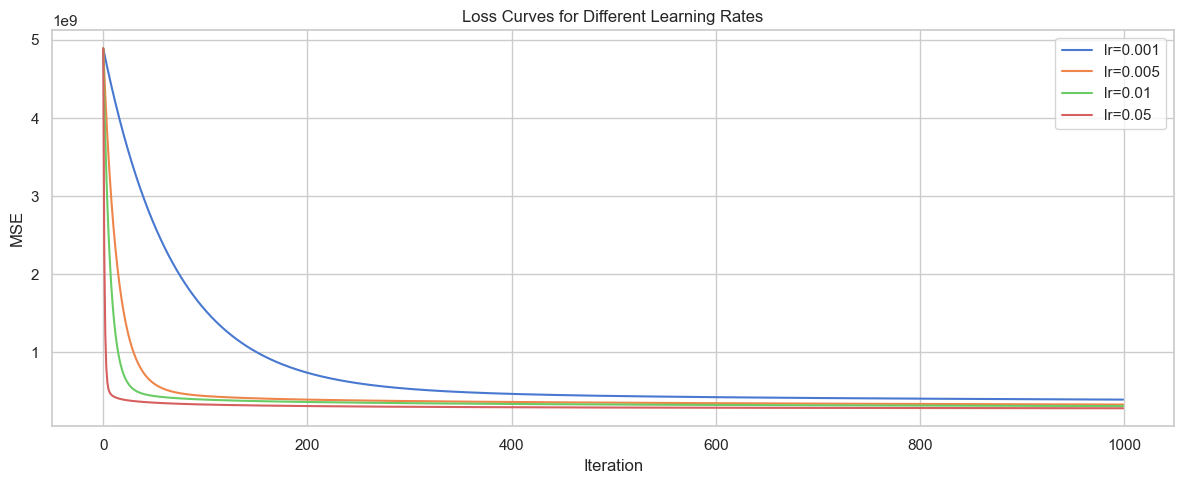

In [19]:
learning_rates = [0.001, 0.005, 0.01, 0.05]
results = {}

for lr in learning_rates:
    m = LinearRegressionGD(learning_rate=lr, n_iterations=1000, verbose=False)
    m.fit(X_train_np, y_train_np)
    r2 = r2_score(y_test_np, m.predict(X_test_np))
    results[lr] = {"model": m, "r2": r2}
    print(f"lr={lr:.3f}  →  Test R²: {r2:.4f}")

plt.figure(figsize=(12, 5))
for lr, res in results.items():
    plt.plot(res["model"].loss_history, label=f"lr={lr}")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Loss Curves for Different Learning Rates")
plt.legend()
plt.tight_layout()
plt.show()


---
## ✅ Summary

| Step | Details |
|------|---------|
| **Dataset** | Laptop prices with specs (CPU, RAM, GPU, Storage…) |
| **EDA** | Bar plots of avg price per feature |
| **Cleaning** | Nulls, duplicates, type conversion |
| **Feature Eng.** | CPU brand/speed, resolution, PPI, memory splits |
| **Encoding** | One-Hot Encoding for categoricals |
| **Scaling** | StandardScaler on numerical columns |
| **Model** | Linear Regression via **Batch Gradient Descent** |
| **Evaluation** | R², RMSE, residuals plot |
| **Tuning** | Learning rate comparison |
